<a href="https://colab.research.google.com/github/humairaneha/Learning-Pytorch/blob/main/Building_a_Spam_Classifier_using_RNN_with_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


In [85]:
torch.manual_seed(42)


In [86]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(device)


cuda


In [87]:
df = pd.read_csv('spam.csv',encoding='latin1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [88]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],axis= 1,inplace=True)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [89]:
df.shape

(5572, 2)

In [90]:
df["v1"].value_counts()

,count
v1,
ham,4825
spam,747


In [91]:
df.isnull().sum()

,0
v1,0
v2,0


In [92]:
df.sample(5)

,v1,v2
3822,ham,Please protect yourself from e-threats. SIB ne...
5535,ham,"I know you are thinkin malaria. But relax, chi..."
4890,ham,Its worse if if uses half way then stops. Its ...
3897,ham,Otherwise had part time job na-tuition..
1116,ham,Hey... What time is your driving on fri? We go...


In [93]:
X = df.iloc[:,1].values
y  = df.iloc[:,0]
y

,v1
0,ham
1,ham
2,spam
3,ham
4,ham
...,...
5567,spam
5568,ham
5569,ham
5570,ham


In [94]:
y = y.map({
    "ham":0,
    "spam":1
}).values


In [95]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [96]:
#split dataset into train and test
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,random_state=42,stratify=y)
X_train,X_val,y_train,y_val= train_test_split(X_train,y_train,test_size=1/9, random_state=42,stratify=y_train)
X_train.shape,X_val.shape,X_test.shape,y_train.shape,y_val.shape,y_test.shape

((4456,), (558,), (558,), (4456,), (558,), (558,))

In [97]:
#basic tokenizer
# word level
def tokenize(text):
  return text.lower().split()


In [98]:
tokenized_train = []
tokenized_val = []
tokenized_test = []

for mail in X_train:
  tokenized_train.append(tokenize(mail))

for mail in X_val:
  tokenized_val.append(tokenize(mail))

for mail in X_test:
  tokenized_test.append(tokenize(mail))




In [99]:
#building vocabulary only for train set
from collections import Counter

word_counter = Counter()

for tokens in tokenized_train:
  word_counter.update(tokens)

#remove rare words

min_freq = 2

word2idx = {
    "<pad>":0,
    "<unk>":1
}

idx2word = {
    0:"<pad>",
    1:"<unk>"
}

for word,count in word_counter.items():
  if(count>=min_freq):
    idx = len(word2idx)
    word2idx[word] =idx
    idx2word[idx] = word

len(word2idx)



4659

In [100]:
# max_length=0

# for sentence in tokenized_train:
#   max_length= max(max_length,len(sentence))

In [101]:
#integer encoding

def encode(sentence):

  encoded_sentence=[]
  for word in sentence:

    if(word in word2idx.keys()):
      encoded_sentence.append(word2idx[word])
    else:
      encoded_sentence.append(word2idx["<unk>"])

  return encoded_sentence




In [102]:
encoded_train = []
for sentence in tokenized_train:
  encoded_train.append(encode(sentence))

encoded_test = []
for sentence in tokenized_test:
  encoded_test.append(encode(sentence))

encoded_val = []
for sentence in tokenized_val:
  encoded_val.append(encode(sentence))




In [103]:
class CustomDataset(Dataset):
  def __init__(self,sequences,labels):
    self.sequences = sequences # Keep as list of lists
    self.labels = torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.sequences)


  def __getitem__(self,idx):
    return torch.tensor(self.sequences[idx], dtype=torch.long),self.labels[idx]

In [104]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):

   sequences, labels = zip(*batch)

   lengths = torch.tensor([len(seq) for seq in sequences],dtype=torch.long)

   padded_sequences = pad_sequence(
       sequences,
       batch_first=True,
       padding_value=0
   )

   return padded_sequences, torch.tensor(labels,dtype=torch.long),lengths






In [105]:

train_dataset = CustomDataset(encoded_train,y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,collate_fn=collate_fn)

val_dataset = CustomDataset(encoded_val,y_val)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False,collate_fn=collate_fn)

test_dataset = CustomDataset(encoded_test,y_test)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False,collate_fn=collate_fn)



In [106]:
class My_RNN(nn.Module):
  def __init__(self, input_dim,hidden_dim):
    super().__init__()

    self.hidden_dim = hidden_dim
    self.x_t = nn.Linear(input_dim , hidden_dim, bias=False )
    self.h_t = nn.Linear(hidden_dim , hidden_dim, bias=True )


  def forward(self,seq):



    h_prev = torch.zeros(1,self.hidden_dim,device=seq.device)

    hidden_states = []

    for seq_t in seq:

      seq_t = seq_t.unsqueeze(0) # [input_dim]--> [[input_dim]]


      h_cur = torch.tanh( self.x_t(seq_t) + self.h_t(h_prev))
      h_prev = h_cur
      hidden_states.append(h_cur)

    return torch.cat(hidden_states,dim=0),h_prev




In [107]:
class SpamClassifier(nn.Module):

  def __init__(self, vocab_size, embedding_dim, hidden_dim, class_dim):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_dim,padding_idx=0) #simply a lookup table
    self.rnn = My_RNN(embedding_dim,hidden_dim)
    self.fc = nn.Linear(hidden_dim,class_dim) # yt = wyht+by

  def forward(self,x,lengths):

    embedded = self.embedding(x)

    outputs=[]

    for single_seq,length in zip(embedded,lengths):
      real_seq = single_seq[:length]
      hidden_states, final_hidden = self.rnn(real_seq)
      outputs.append(final_hidden) # for classifer we are only interested in the final hidden states

    final_hidden_batch = torch.cat(outputs,dim=0)
    logits = self.fc(final_hidden_batch)
    return logits


In [108]:
epochs=20
learning_rate = 0.001

In [109]:
vocab_size = len(word2idx)
embedding_dim=100
hidden_dim=128 # Increased hidden_dim
class_dim=2

# Calculate class weights for imbalanced dataset
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

model = SpamClassifier(vocab_size,embedding_dim,hidden_dim,class_dim)
model.to(device)
criterion = nn.CrossEntropyLoss() # Apply class weights to the loss function
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [110]:
patience = 5

In [111]:
#training loop

best_val_loss = float('inf')
train_losses=[]
train_accuracies=[]
val_losses=[]
val_accuracies=[]

for epoch in range(epochs):

  model.train()

  train_loss=0
  train_correct=0
  train_total=0

  for batch_train,batch_labels,lengths in train_loader:

    batch_train = batch_train.to(device)
    batch_labels = batch_labels.to(device)
    lengths = lengths.to(device)

    #clear old gradients
    optimizer.zero_grad()
    #froward pass
    outputs = model(batch_train,lengths)

    #loss

    loss = criterion(outputs,batch_labels)

    #backpropagation

    loss.backward()

    #update weights

    optimizer.step()

    train_loss+=loss.item()

    predicted = torch.argmax(outputs,dim=1)
    train_total+=len(batch_labels)
    train_correct+= (predicted==batch_labels).sum().item()

  train_accuracy = train_correct/train_total
  avg_train_loss = train_loss/len(train_loader)

  #Validation

  model.eval()

  val_loss=0
  val_correct=0
  val_total=0

  with torch.no_grad():

    for batch_val, batch_labels,lengths in val_loader:

      batch_val = batch_val.to(device)
      batch_labels = batch_labels.to(device)
      lengths= lengths.to(device)

      outputs = model(batch_val,lengths)
      loss= criterion(outputs,batch_labels)
      val_loss+=loss.item()

      predicted = torch.argmax(outputs,dim=1)
      val_total+=len(batch_labels)
      val_correct+= (predicted==batch_labels).sum().item()

    val_accuracy = val_correct/val_total
    avg_val_loss = val_loss/len(val_loader)

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)



    print(f"Epoch {epoch+1}/{epochs}"),
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Train Acc: {train_accuracy:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}")
    print(f"Val Acc: {val_accuracy:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_spam_rnn_model.pth")
        print("Best model saved.")
    else:
        patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break



Epoch 1/20
Train Loss: 0.3104
Train Acc: 0.8853
Val Loss: 0.1613
Val Acc: 0.9373
Best model saved.
Epoch 2/20
Train Loss: 0.1324
Train Acc: 0.9560
Val Loss: 0.0878
Val Acc: 0.9695
Best model saved.
Epoch 3/20
Train Loss: 0.0806
Train Acc: 0.9758
Val Loss: 0.0902
Val Acc: 0.9731
Epoch 4/20
Train Loss: 0.0648
Train Acc: 0.9814
Val Loss: 0.0668
Val Acc: 0.9821
Best model saved.
Epoch 5/20
Train Loss: 0.0411
Train Acc: 0.9886
Val Loss: 0.1408
Val Acc: 0.9677
Epoch 6/20
Train Loss: 0.0233
Train Acc: 0.9948
Val Loss: 0.0783
Val Acc: 0.9767
Epoch 7/20
Train Loss: 0.0317
Train Acc: 0.9899
Val Loss: 0.0803
Val Acc: 0.9713
Epoch 8/20
Train Loss: 0.0252
Train Acc: 0.9930
Val Loss: 0.0881
Val Acc: 0.9713
Epoch 9/20
Train Loss: 0.0126
Train Acc: 0.9969
Val Loss: 0.1153
Val Acc: 0.9642
Early stopping triggered.


In [112]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

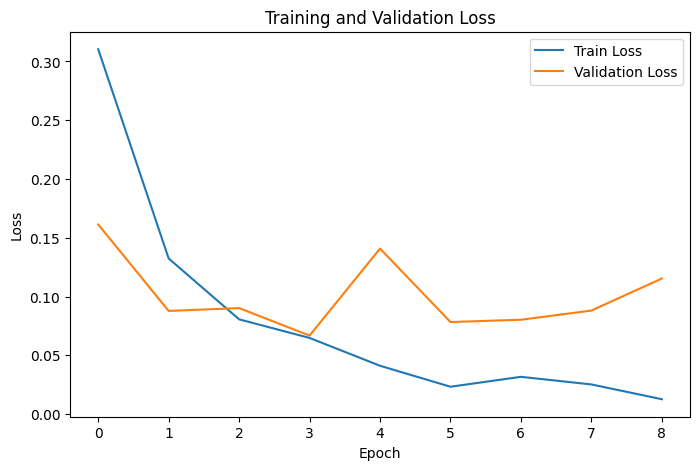

In [113]:
#plot losses
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

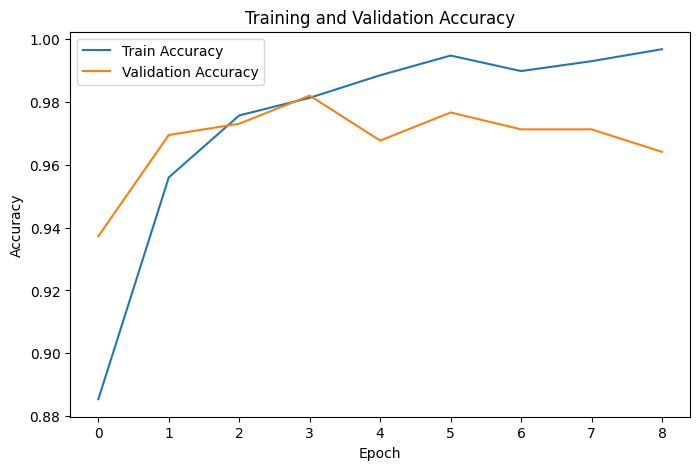

In [115]:
#accuracy plot

plt.figure(figsize=(8,5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

In [116]:
#load best model
model.load_state_dict(torch.load("best_spam_rnn_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y, lengths in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        lengths = lengths.to(device)

        logits = model(batch_X, lengths)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

In [117]:
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["ham", "spam"]))

precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Confusion Matrix:
[[476   7]
 [ 12  63]]

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      0.99      0.98       483
        spam       0.90      0.84      0.87        75

    accuracy                           0.97       558
   macro avg       0.94      0.91      0.92       558
weighted avg       0.97      0.97      0.97       558

Precision: 0.9000
Recall: 0.8400
F1-score: 0.8690
